# Multi-event reconstruction with cuts

Apply the current event-selection cuts, reconstruct a sample of events, summarize performance, and finish with one example event display.

## Bootstrap project imports

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents):
    if (candidate / "src").exists() and (candidate / "notebooks").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate reco_algorithm_tests project root.")

src_dir = PROJECT_ROOT / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print(f"Project root: {PROJECT_ROOT}")


Project root: /workdir/playground/reco_algorithm_tests


## Import reconstruction and plotting tools

In [2]:
import numpy as np
from tqdm.notebook import tqdm

from algorithms import (
    DefaultPatternFormer,
    DefaultTrackletFormer,
    TrackletGroupingValidator,
    TypeScoringVertexFormer,
    print_registered_algorithms,
)
from data_io import (
    AllowedAtarParticlesCut,
    AtarFiducialCut,
    DelayedLysoClusterCut,
    EmptyEventCut,
    NoElectronAtarHitsCut,
    RequirePionAtarHitCut,
    RecoDataFile,
    load_pioneer_libraries,
    print_file_creation_time,
    print_registered_cuts,
)
from figures import DetectorEventViewFigure, EventDisplayFigure, EventPatternsSummaryFigure, PatternClassificationFigure
from pipeline import Pipeline
from pipeline.stages import (
    EventInputStage,
    EventInitStage,
    InputContext,
    PatternStage,
    TrackletStage,
    ValidationStage,
    VertexStage,
)


## Load PIONEER shared libraries

In [3]:
load_pioneer_libraries()

## Locate the current smoke-test ROOT file

In [4]:
DATA_DIR = (PROJECT_ROOT / ".data" / "current").resolve()
reco_file = str(DATA_DIR / "all_rec.root")

print_file_creation_time(reco_file)


The file '/workdir/playground/reco_algorithm_tests/.data/current/all_rec.root' was created on: 2026-06-17 14:48:17


## Open the reconstructed data file and define cuts

In [5]:
print_registered_cuts()

reco_data = RecoDataFile(
    reco_file,
    profile="realistic",
    cuts=[
        EmptyEventCut(enabled=True),
        AllowedAtarParticlesCut(enabled=True),
        NoElectronAtarHitsCut(enabled=True),
        RequirePionAtarHitCut(enabled=True),
        AtarFiducialCut(max_abs_coordinate=8.0, enabled=True),
        DelayedLysoClusterCut(
            min_cluster_energy_mev=10.0,
            window_start_ns=0.0,
            window_stop_ns=700.0,
            cluster_gap_ns=5.0,
            enabled=True,
        ),
    ],
)

print(f"Loaded {reco_data.entries} reconstructed events from {reco_file}")
print(f"Truth collections available: {reco_data.has_truth_entry}")
print("Enabled cuts:", [cut.name for cut in reco_data.cut_flow.enabled_cuts()])


cuts:
  allowed_atar_particles (AllowedAtarParticlesCut) - Reject entries containing reconstructed ATAR hits from particles outside a configurable allowed PID set.
    parameters:
      allowed_particle_ids: Iterable of integer particle IDs allowed to appear in reconstructed ATAR hits.
      enabled: Set False to leave the cut configured but inactive.
    example: AllowedAtarParticlesCut(allowed_particle_ids={211, -211, 13, -13, 11, -11}, enabled=True)
  atar_fiducial (AtarFiducialCut) - Require reconstructed ATAR tracklet hits to stay inside a simple front/back fiducial window.
    parameters:
      max_abs_coordinate: Maximum allowed |x| or |y| in mm for front/back ATAR hits.
      enabled: Set False to keep the cut in the list without applying it.
    example: AtarFiducialCut(max_abs_coordinate=8.0, enabled=True)
  delayed_lyso_cluster (DelayedLysoClusterCut) - Require one delayed LYSO activity cluster above threshold within a time window.
    parameters:
      min_cluster_energy_me

## Select events that pass the current cut flow

In [6]:
MAX_EVENTS = None
all_events = reco_data.selected_entries(max_entries=MAX_EVENTS, progress=tqdm)
print(f"Selected {len(all_events)} / {reco_data.entries} entries")
reco_data.print_cut_table()


Applying dataset cuts:   0%|          | 0/727 [00:00<?, ?it/s]

Selected 35 / 727 entries
cut                         removed  removed %   cumulative   cumulative %
--------------------------------------------------------------------------
nonempty_event                   24      3.30%           24          3.30%
allowed_atar_particles            1      0.14%           25          3.44%
no_electron_atar_hits            22      3.03%           47          6.46%
require_pion_atar_hit             3      0.41%           50          6.88%
atar_fiducial                   187     25.72%          237         32.60%
delayed_lyso_cluster            455     62.59%          692         95.19%
--------------------------------------------------------------------------
TOTAL                           692     95.19%          692         95.19%
KEPT                             35      4.81%           35          4.81%
Scanned entries: 727


## Build the reconstruction pipeline

In [7]:
print_registered_algorithms()

pipeline = Pipeline()
pipeline.register_stage(EventInputStage())
pipeline.register_stage(EventInitStage())
pipeline.register_stage(TrackletStage(DefaultTrackletFormer()))
pipeline.register_stage(VertexStage(TypeScoringVertexFormer()))
pipeline.register_stage(PatternStage(DefaultPatternFormer()))
pipeline.register_stage(ValidationStage(TrackletGroupingValidator()))

print("Pipeline registered with stages:")
for stage_key, stage in pipeline.registered_stages.items():
    print(f"  {stage}")


pattern:
  default (DefaultPatternFormer) - Build patterns as connected components in the shared-tracklet vertex graph.
    parameters: none
    example: DefaultPatternFormer()
  known_patterns (KnownPatternsPatternFormer) - Rebuild patterns from the input tracklets' stored reconstructed pattern IDs.
    parameters: none
    example: KnownPatternsPatternFormer()
tracklet:
  default (DefaultTrackletFormer) - Wrap the active ATAR tracklet collections, attach fit results, and derive display-safe endpoints.
    parameters: none
    example: DefaultTrackletFormer()
  known_patterns (KnownPatternsTrackletFormer) - Build tracklets by following existing reconstructed pattern membership from the input file.
    parameters: none
    example: KnownPatternsTrackletFormer()
validation:
  tracklet_grouping (TrackletGroupingValidator) - Check that reconstructed pattern tracklet groupings match the stored truth grouping.
    parameters:
      verbose: int, default=0
    example: TrackletGroupingValida

## Reconstruct the selected events

In [8]:
N_EVENTS = -1

if N_EVENTS == -1 or N_EVENTS > len(all_events):
    events_to_process = all_events
else:
    events_to_process = all_events[:N_EVENTS]

reconstructed_events = np.empty(len(events_to_process), dtype=object)

with tqdm(total=len(events_to_process), desc="Reconstructing events") as pbar:
    for i, event_index in enumerate(events_to_process):
        input_context = InputContext(reco_data, event_index)
        pipeline.run(input_context)
        reconstructed_events[i] = pipeline.get_event()
        pbar.update(1)


Reconstructing events:   0%|          | 0/35 [00:00<?, ?it/s]

## Performance vs. reconstructed particle composition

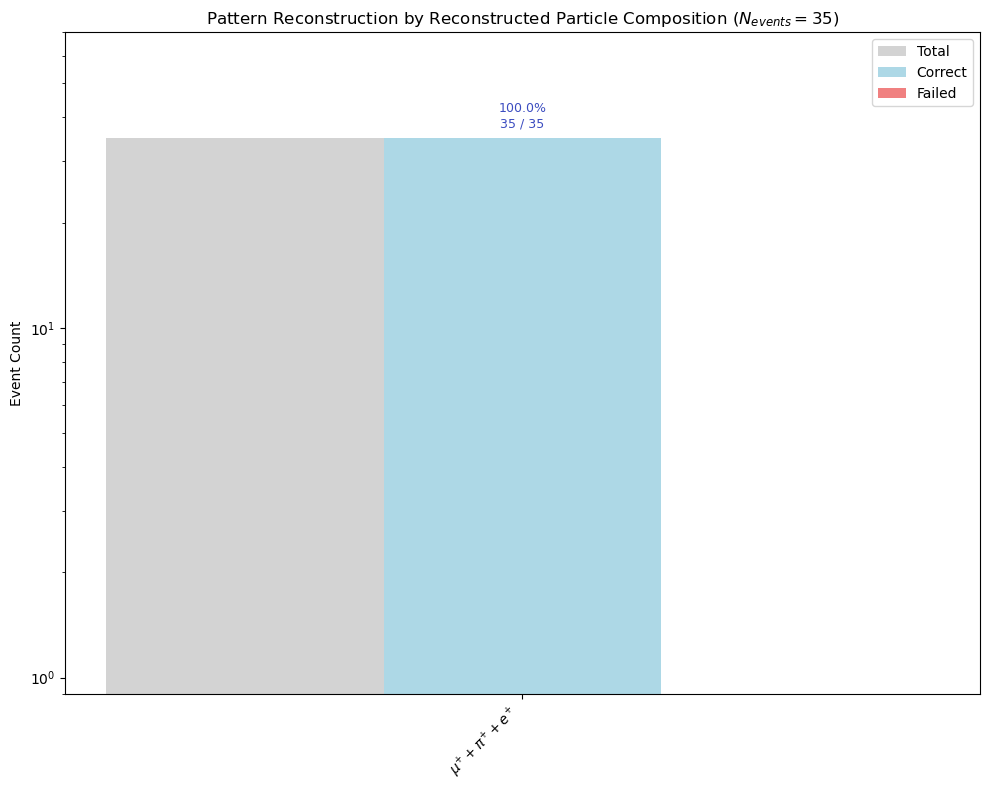

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Pattern Reconstruction by Reconstructed Particle Composition ($N_{events} = 35$)'}, ylabel='Event Count'>)

In [9]:
title = f"Pattern Reconstruction by Reconstructed Particle Composition ($N_{{events}} = {len(reconstructed_events)}$)"
PatternClassificationFigure(particle_source="pattern_reco", title=title).draw(reconstructed_events)


## Performance vs. truth particle composition

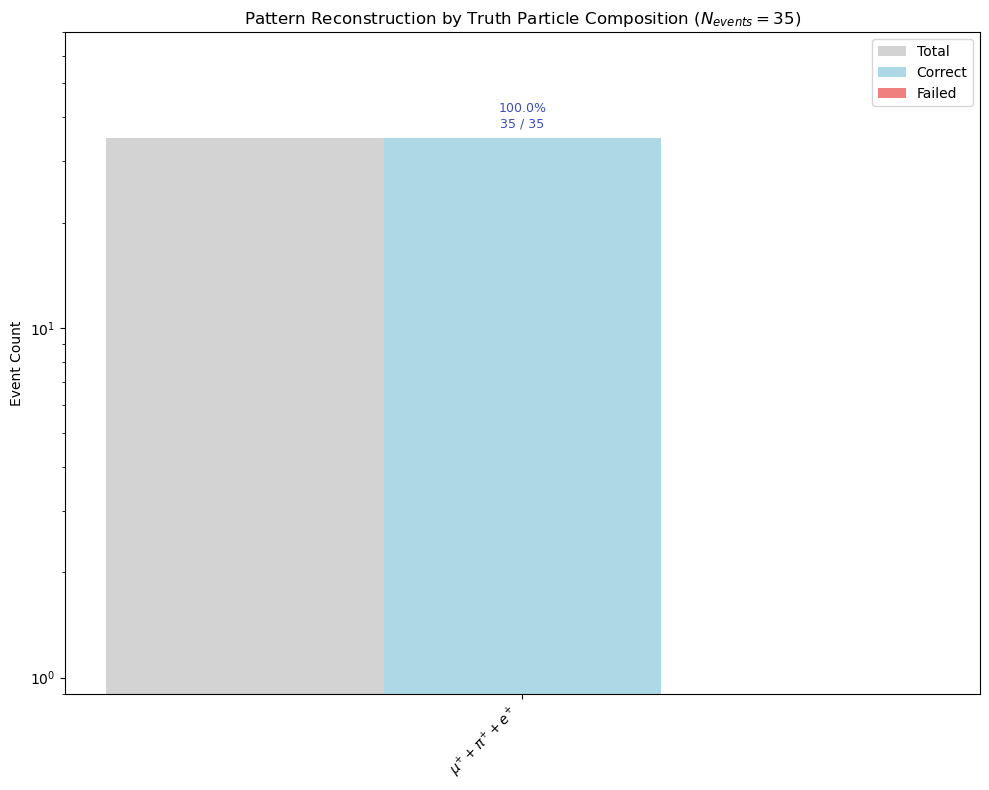

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Pattern Reconstruction by Truth Particle Composition ($N_{events} = 35$)'}, ylabel='Event Count'>)

In [10]:
title = f"Pattern Reconstruction by Truth Particle Composition ($N_{{events}} = {len(reconstructed_events)}$)"
PatternClassificationFigure(particle_source="truth", title=title).draw(reconstructed_events)


## Performance vs. true number of patterns

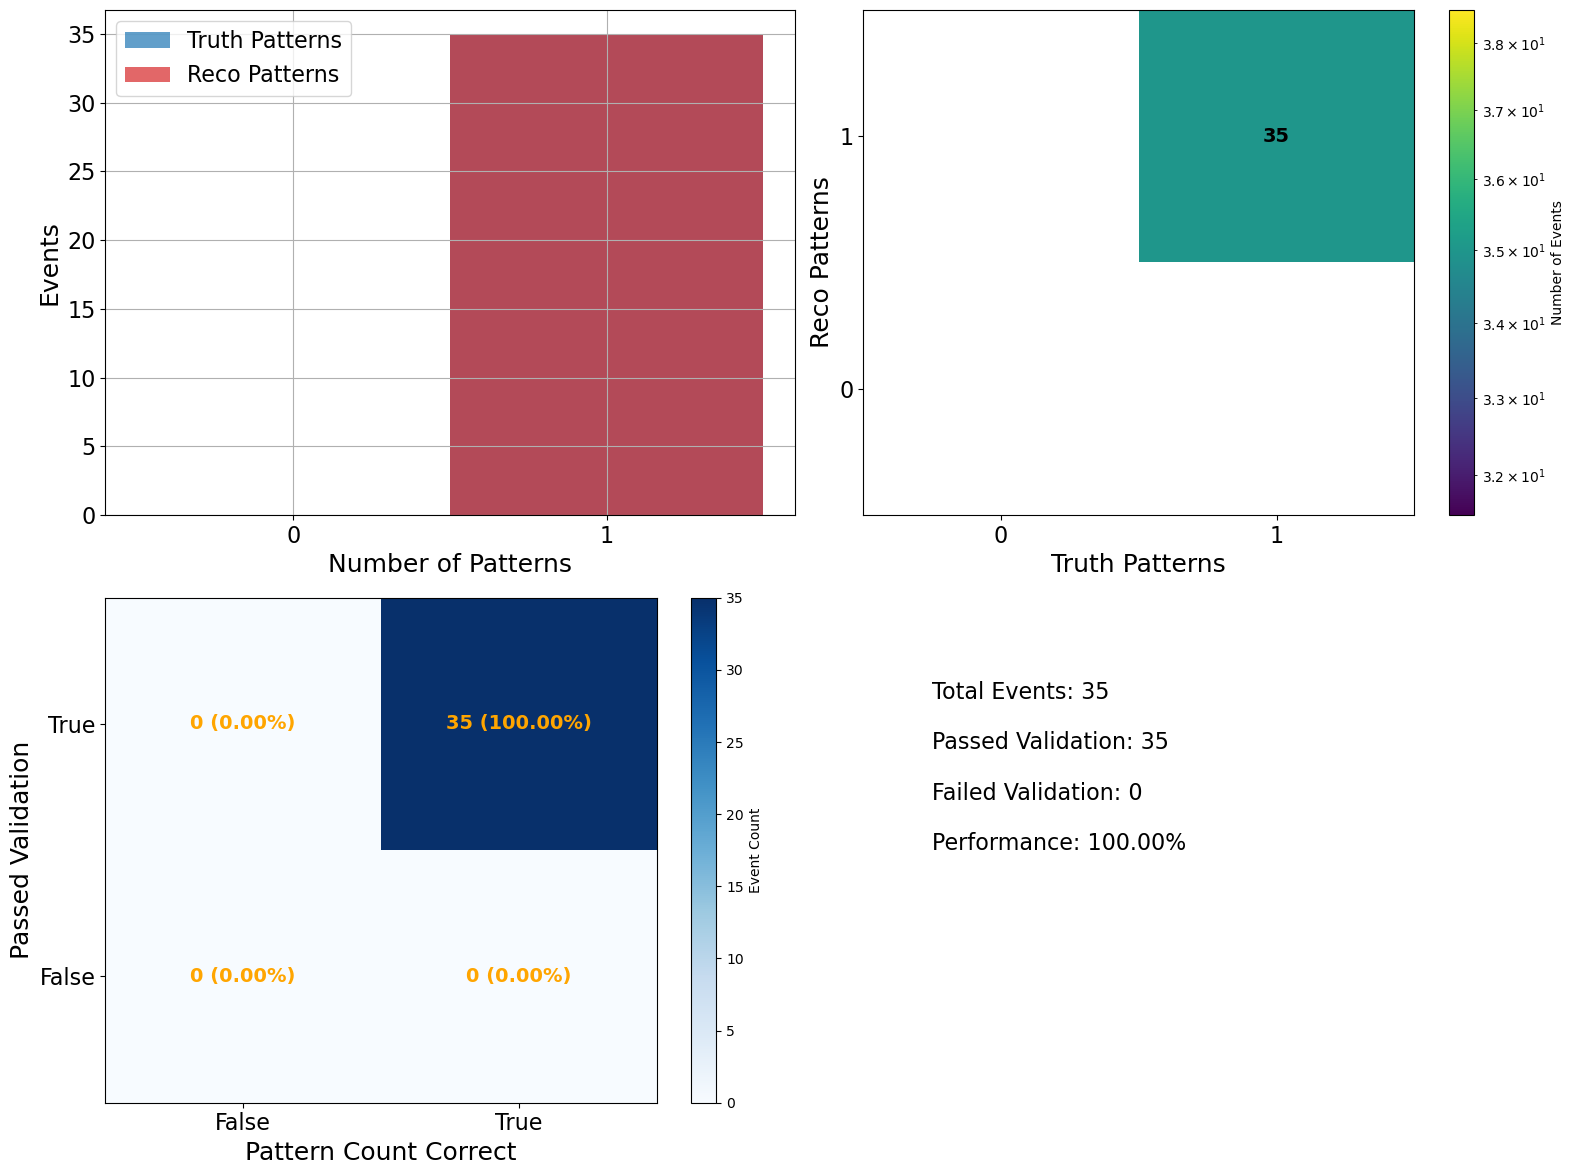

(<Figure size 1600x1200 with 6 Axes>,
 array([[<Axes: xlabel='Number of Patterns', ylabel='Events'>,
         <Axes: xlabel='Truth Patterns', ylabel='Reco Patterns'>],
        [<Axes: xlabel='Pattern Count Correct', ylabel='Passed Validation'>,
         <Axes: >]], dtype=object))

In [11]:
EventPatternsSummaryFigure(title=None).draw(reconstructed_events)

## Example reconstructed event display

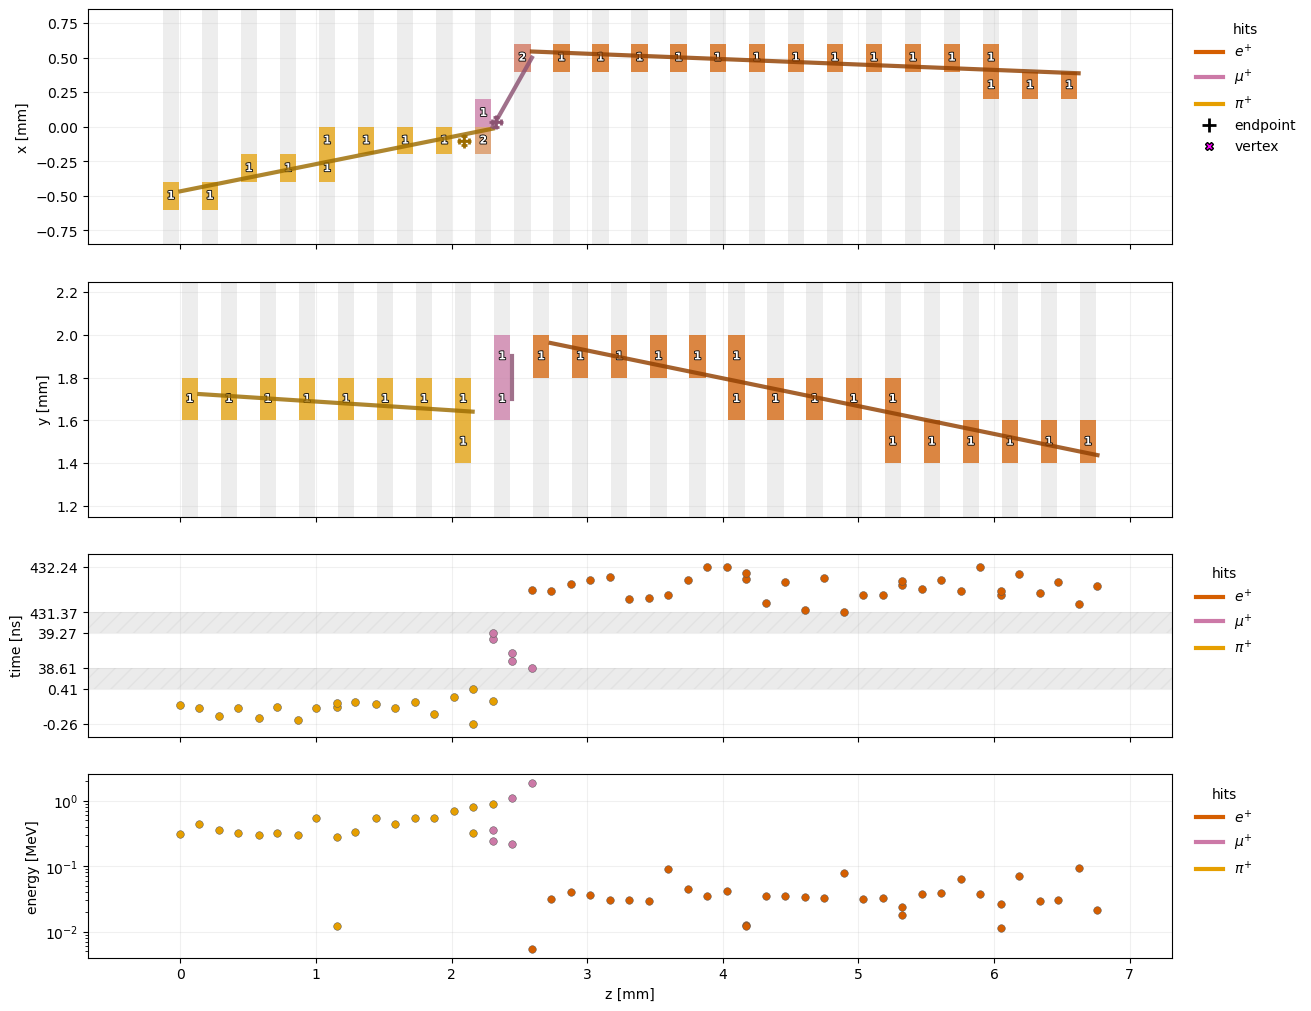

In [12]:
example_event = None

if example_event is None and len(reconstructed_events):
    example_event = reconstructed_events[0]

if example_event is None:
    print("No reconstructed events available to display.")
else:
    EventDisplayFigure().draw(example_event)
